In [2]:
import pandas as pd
import numpy as np
import lifelines
from patsy import dmatrix
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from lifelines import KaplanMeierFitter
from lifelines.utils import concordance_index
from lifelines import CoxPHFitter
from sklearn.metrics import log_loss
from sklearn.metrics import brier_score_loss
from sklearn.calibration import calibration_curve
from sklearn.isotonic import IsotonicRegression
import matplotlib.cm as cm  
import matplotlib.ticker as mticker

In [3]:
df_train = pd.read_csv('df_train_cph5.csv')
df_test = pd.read_csv('df_test_cph5.csv') 

In [4]:
formula="bs(BMICALC, degree=2, df=3) + bs(HRSLEEP, degree=1, df=2) + bs(STRONGFWK, degree=2, df=2) + bs(ALCDAYSYR, degree=1, df=2) + bs(ALCAMT, degree=2, df=2) + bs(POVERTY, degree=2, df=2) +" + " + ".join(df_train.columns.difference(['TIMETOEVENT', 'MORTSTAT','BMICALC', 'HRSLEEP', 'STRONGFWK', 'ALCDAYSYR', 'ALCAMT', 'POVERTY']))

cph = CoxPHFitter()
cph.fit(df_train,
        duration_col='TIMETOEVENT', 
        event_col='MORTSTAT',
        formula=formula)

<lifelines.CoxPHFitter: fitted with 82720 total observations, 78101 right-censored observations>

In [5]:
# predict the survival function for each individual
survival_function_train = cph.predict_survival_function(df_train)
survival_function_test = cph.predict_survival_function(df_test)

# extract 3y survival probabilities
survival_prob_3y_train = survival_function_train.iloc[3] 
survival_prob_3y_test = survival_function_test.iloc[3] 

# get 3-year event status based on TIMETOEVENT and MORTSTAT
status_3y_train = np.where((df_train["MORTSTAT"] == 1) & (df_train["TIMETOEVENT"] <= 3), 0, 1)
status_3y_test = np.where((df_test["MORTSTAT"] == 1) & (df_test["TIMETOEVENT"] <= 3), 0, 1)

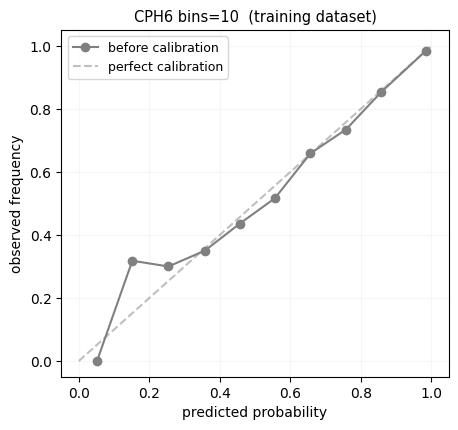

In [6]:
# calibration curve as expalined in the thesis
prob_true_train, prob_pred_train = calibration_curve(status_3y_train, survival_prob_3y_train, n_bins=10, strategy='uniform')

# -- plot ---
plt.figure(figsize=(5, 4.5))
plt.plot(prob_pred_train, prob_true_train, marker='o', label="before calibration", color="gray")
plt.plot([0,1], [0,1], linestyle='--', color='grey', label="perfect calibration", alpha=0.5)
plt.xlabel("predicted probability")
plt.ylabel("observed frequency")
plt.title("CPH6 bins=10  (training dataset)", fontsize=10.5)
plt.legend(fontsize=9)
plt.grid(alpha=0.1)
plt.savefig('cox_train_10.png', format='png', dpi=300, bbox_inches='tight')
plt.show()

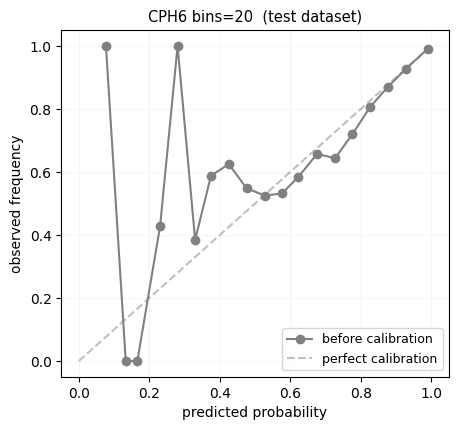

In [7]:
# calibration curve
prob_true_test, prob_pred_test = calibration_curve(status_3y_test, survival_prob_3y_test, n_bins=20, strategy='uniform')

# -- plot ---
plt.figure(figsize=(5, 4.5))
plt.plot(prob_pred_test, prob_true_test, marker='o', label="before calibration", color="gray")
plt.plot([0,1], [0,1], linestyle='--', color='grey', label="perfect calibration", alpha=0.5)
plt.xlabel("predicted probability")
plt.ylabel("observed frequency")
plt.title("CPH6 bins=20  (test dataset)", fontsize=10.5)
plt.legend(fontsize=9)
plt.grid(alpha=0.1)
plt.savefig('cox_test_20.png', format='png', dpi=300, bbox_inches='tight')
plt.show()

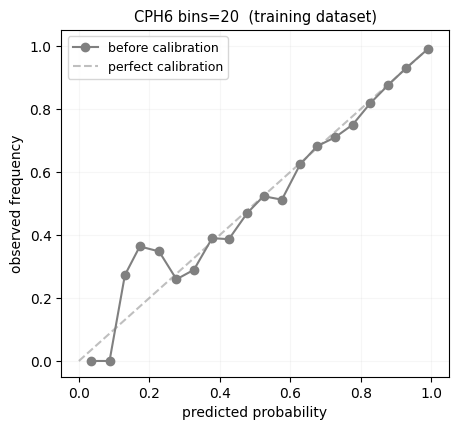

In [8]:
# calibration curve 
prob_true_train, prob_pred_train = calibration_curve(status_3y_train, survival_prob_3y_train, n_bins=20, strategy='uniform')

# -- plot ---
plt.figure(figsize=(5, 4.5))
plt.plot(prob_pred_train, prob_true_train, marker='o', label="before calibration", color="gray")
plt.plot([0,1], [0,1], linestyle='--', color='grey', label="perfect calibration", alpha=0.5)
plt.xlabel("predicted probability")
plt.ylabel("observed frequency")
plt.title("CPH6 bins=20  (training dataset)", fontsize=10.5)
plt.legend(fontsize=9)
plt.grid(alpha=0.1)
plt.savefig('cox_train_20.png', format='png', dpi=300, bbox_inches='tight')
plt.show()

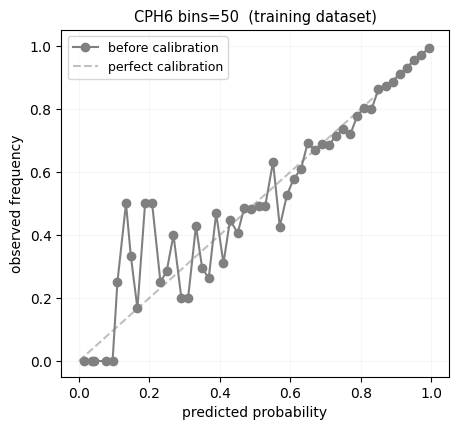

In [9]:
# calibration curve (binning predicted probs)
prob_true_train, prob_pred_train = calibration_curve(status_3y_train, survival_prob_3y_train, n_bins=50, strategy='uniform')

# -- plot ---
plt.figure(figsize=(5, 4.5))
plt.plot(prob_pred_train, prob_true_train, marker='o', label="before calibration", color="gray")
plt.plot([0,1], [0,1], linestyle='--', color='grey', label="perfect calibration", alpha=0.5)
plt.xlabel("predicted probability")
plt.ylabel("observed frequency")
plt.title("CPH6 bins=50  (training dataset)", fontsize=10.5)
plt.legend(fontsize=9)
plt.grid(alpha=0.1)
plt.savefig('cox_train_50.png', format='png', dpi=300, bbox_inches='tight')
plt.show()

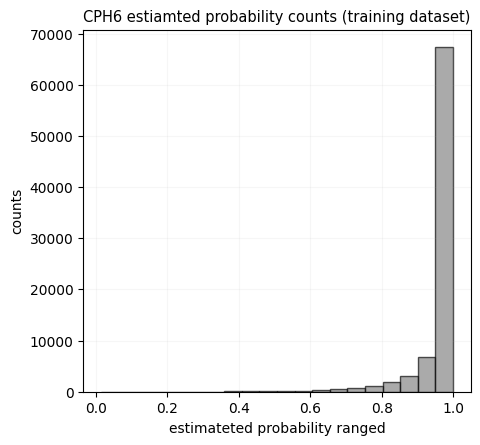

In [10]:
plt.figure(figsize=(5, 4.7))
plt.hist(survival_prob_3y_train, bins=20, color="grey", edgecolor="black", alpha=0.67)
plt.xlabel("estimateted probability ranged")
plt.ylabel("counts")
plt.title("CPH6 estiamted probability counts (training dataset)", fontsize=10.5)
plt.grid(alpha=0.1)
plt.savefig('cox_count_20.png', format='png', dpi=300, bbox_inches='tight')
plt.show()

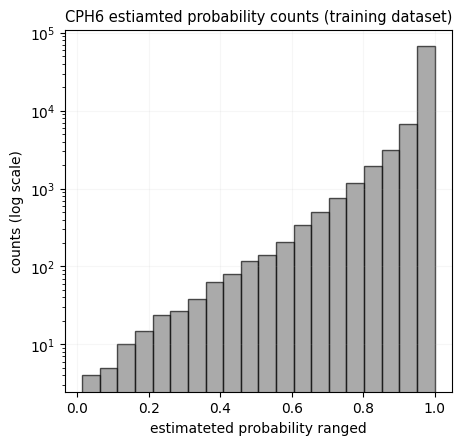

In [11]:
plt.figure(figsize=(5, 4.7))
plt.hist(survival_prob_3y_train, bins=20, color="grey", edgecolor="black", alpha=0.67)
plt.yscale('log')
plt.xlabel("estimateted probability ranged")
plt.ylabel("counts (log scale)")
plt.title("CPH6 estiamted probability counts (training dataset)", fontsize=10.5)
plt.grid(alpha=0.1)
plt.savefig('cox_count_log_20.png', format='png', dpi=300, bbox_inches='tight')
plt.show()

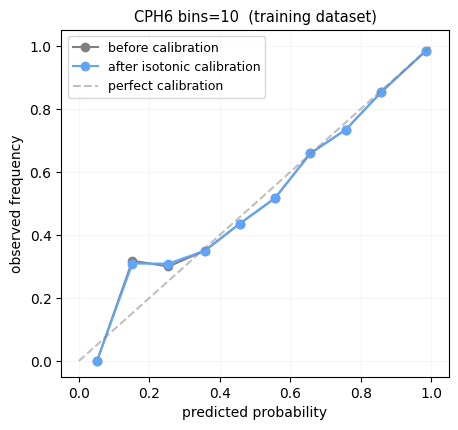

In [12]:
# step 1: calibration curve 
prob_true_train, prob_pred_train = calibration_curve(status_3y_train, survival_prob_3y_train, n_bins=10, strategy='uniform')

# step 2: fit isotonic regression to training dataset estiamates
iso_reg = IsotonicRegression(out_of_bounds="clip")
iso_reg.fit(prob_pred_train, prob_true_train)

# --- plot ---
plt.figure(figsize=(5, 4.5))
plt.plot(prob_pred_train, prob_true_train, marker='o', label="before calibration", color="gray")
plt.plot(prob_pred_train, iso_reg.predict(prob_pred_train), marker='o', label="after isotonic calibration", color='#60A5FA')
plt.plot([0,1], [0,1], linestyle='--', color='grey', label="perfect calibration", alpha=0.5)
plt.xlabel("predicted probability")
plt.ylabel("observed frequency")
plt.title("CPH6 bins=10  (training dataset)", fontsize=10.5)
plt.legend(fontsize=9)
plt.grid(alpha=0.1)
plt.savefig('iso_cox_10.png', format='png', dpi=300, bbox_inches='tight')
plt.show()

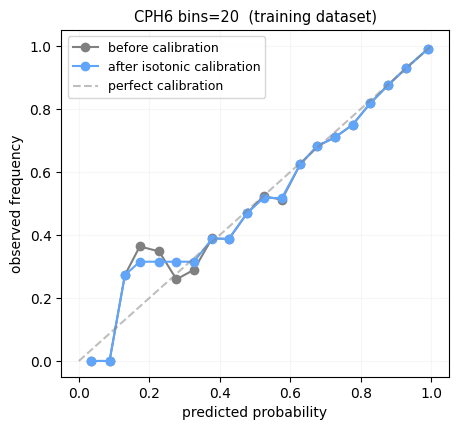

In [13]:
# step 1: calibration curve 
prob_true_train, prob_pred_train = calibration_curve(status_3y_train, survival_prob_3y_train, n_bins=20, strategy='uniform')

# step 2: fit isotonic regression to training dataset estiamates
iso_reg = IsotonicRegression(out_of_bounds="clip")
iso_reg.fit(prob_pred_train, prob_true_train)

# --- plot ---
plt.figure(figsize=(5, 4.5))
plt.plot(prob_pred_train, prob_true_train, marker='o', label="before calibration", color="gray")
plt.plot(prob_pred_train, iso_reg.predict(prob_pred_train), marker='o', label="after isotonic calibration", color='#60A5FA')
plt.plot([0,1], [0,1], linestyle='--', color='grey', label="perfect calibration", alpha=0.5)
plt.xlabel("predicted probability")
plt.ylabel("observed frequency")
plt.title("CPH6 bins=20  (training dataset)", fontsize=10.5)
plt.legend(fontsize=9)
plt.grid(alpha=0.1)
plt.savefig('iso_cox_20.png', format='png', dpi=300, bbox_inches='tight')
plt.show()

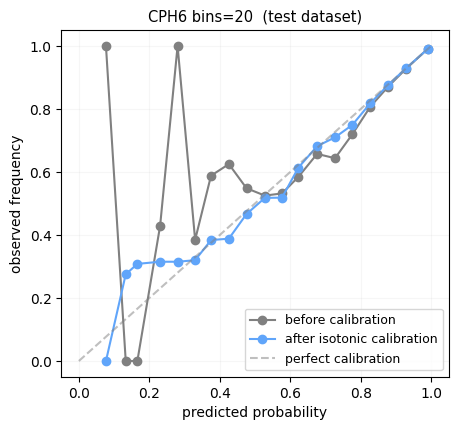

In [14]:
# calibration curve
prob_true_test, prob_pred_test = calibration_curve(status_3y_test, survival_prob_3y_test, n_bins=20, strategy='uniform')

# --- plot ---
plt.figure(figsize=(5, 4.5))
plt.plot(prob_pred_test, prob_true_test, marker='o', label="before calibration", color="gray")
plt.plot(prob_pred_test, iso_reg.predict(prob_pred_test), marker='o', label="after isotonic calibration", color='#60A5FA')
plt.plot([0,1], [0,1], linestyle='--', color='grey', label="perfect calibration", alpha=0.5)
plt.xlabel("predicted probability")
plt.ylabel("observed frequency")
plt.title("CPH6 bins=20  (test dataset)", fontsize=10.5)
plt.legend(fontsize=9)
plt.grid(alpha=0.1)
plt.savefig('iso_cox_test_20.png', format='png', dpi=300, bbox_inches='tight')
plt.show()

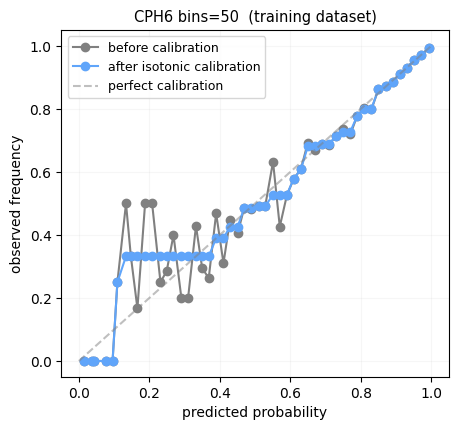

In [15]:
# step 1: calibration curve 
prob_true_train, prob_pred_train = calibration_curve(status_3y_train, survival_prob_3y_train, n_bins=50, strategy='uniform')

# step 2: fit isotonic regression to training dataset estiamates
iso_reg = IsotonicRegression(out_of_bounds="clip")
iso_reg.fit(prob_pred_train, prob_true_train)

# --- plot --
plt.figure(figsize=(5, 4.5))
plt.plot(prob_pred_train, prob_true_train, marker='o', label="before calibration", color="gray")
plt.plot(prob_pred_train, iso_reg.predict(prob_pred_train), marker='o', label="after isotonic calibration", color='#60A5FA')
plt.plot([0,1], [0,1], linestyle='--', color='grey', label="perfect calibration", alpha=0.5)
plt.xlabel("predicted probability")
plt.ylabel("observed frequency")
plt.title("CPH6 bins=50  (training dataset)", fontsize=10.5)
plt.legend(fontsize=9)
plt.grid(alpha=0.1)
plt.savefig('iso_cox_50.png', format='png', dpi=300, bbox_inches='tight')
plt.show()

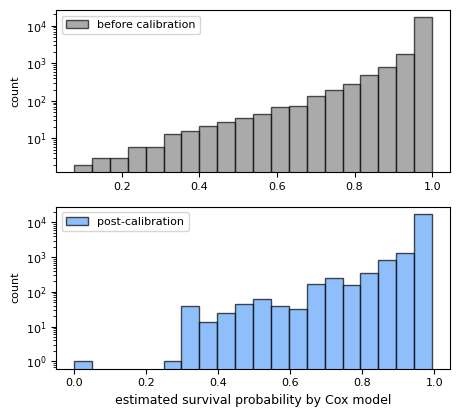

In [16]:
fig, axes = plt.subplots(2, 1, figsize=(4.7, 4.27))  

# standard scale histogram 
axes[0].hist(survival_prob_3y_test, bins=20, color="grey", edgecolor="black", label="before calibration", alpha=0.67)
axes[0].set_ylabel("count", fontsize=8)
axes[0].set_yscale('log')
axes[0].tick_params(axis='both', labelsize=8)
axes[0].legend(fontsize=8, loc="upper left") 

# log scale histogram 
axes[1].hist(iso_reg.predict(survival_prob_3y_test), bins=20, color="#60A5FA", edgecolor="black", label="post-calibration", alpha=0.7)
axes[1].set_yscale('log')
axes[1].set_xlabel("estimated survival probability by Cox model", fontsize=9)
axes[1].set_ylabel("count", fontsize=8)
axes[1].tick_params(axis='both', labelsize=8)
axes[1].legend(fontsize=8, loc="upper left") 

plt.tight_layout()
plt.savefig('sp_count_comparison_testset.png', format='png', dpi=300, bbox_inches='tight')
plt.show()

In [17]:
bin_values = np.arange(10, 205, 5)  

def format_4_decimals(x, pos):
    return f"{x:.4f}"

# initialize lists to store results
log_loss_train_results = []
log_loss_test_results = []
brier_train_results = []
brier_test_results = []
c_train_results = []
c_test_results = []


# loop over different bin values
for bins in bin_values:
    # compute calibration curve
    prob_true_train, prob_pred_train = calibration_curve(status_3y_train, survival_prob_3y_train, n_bins=bins)

    #handle duplicates by averaging observed probabilities
    unique_prob_pred, indices = np.unique(prob_pred_train, return_inverse=True)
    avg_prob_true = np.zeros_like(unique_prob_pred, dtype=float)

    for i in range(len(unique_prob_pred)):
        avg_prob_true[i] = np.mean(prob_true_train[indices == i])    # average duplicates

    # fit Isotonic Regression
    iso_reg = IsotonicRegression(out_of_bounds="clip")
    iso_reg.fit(unique_prob_pred, avg_prob_true)  

    # transform Predictions
    prob_3y_train_iso = iso_reg.transform(survival_prob_3y_train)
    prob_3y_test_iso = iso_reg.transform(survival_prob_3y_test)

    # compute log-loss
    log_loss_train = log_loss(status_3y_train, prob_3y_train_iso)
    log_loss_test = log_loss(status_3y_test, prob_3y_test_iso)
    # store results
    log_loss_train_results.append(log_loss_train)
    log_loss_test_results.append(log_loss_test)
    
    # compute 
    brier_train = brier_score_loss(status_3y_train, prob_3y_train_iso)
    brier_test = brier_score_loss(status_3y_test, prob_3y_test_iso)
    # store results
    brier_train_results.append(brier_train)
    brier_test_results.append(brier_test)
    
    # compute 
    c_index_train = concordance_index(df_train["TIMETOEVENT"], prob_3y_train_iso, df_train["MORTSTAT"])
    c_index_test = concordance_index(df_test["TIMETOEVENT"], prob_3y_test_iso, df_test["MORTSTAT"])
    # store results
    c_train_results.append(c_index_train)
    c_test_results.append(c_index_test)

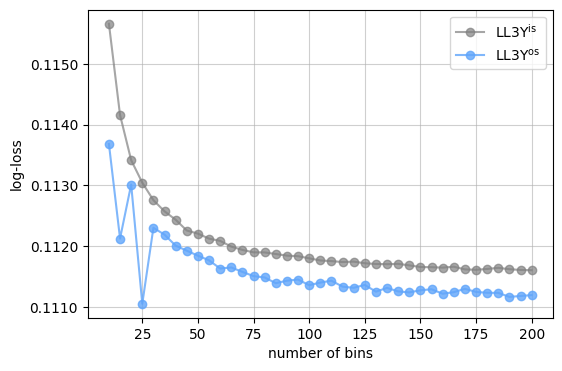

In [18]:
# --- plot ---
plt.figure(figsize=(6, 4))
plt.plot(bin_values, log_loss_train_results, marker='o', label=r"LL3Y$^{\text{is}}$", color='gray', alpha=0.7)
plt.plot(bin_values, log_loss_test_results, marker='o', label=r"LL3Y$^{\text{os}}$", color='#60A5FA',  alpha=0.8)
plt.xlabel("number of bins")
plt.ylabel("log-loss")
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(format_4_decimals))
plt.legend()
plt.grid(True, alpha=0.6)
plt.savefig(f'll_cali.png', format='png', dpi=300, bbox_inches='tight')
plt.show()

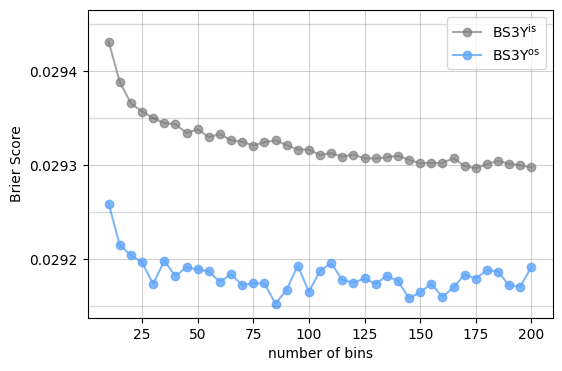

In [19]:
# --- plot ---
plt.figure(figsize=(6, 4))
plt.plot(bin_values, brier_train_results, marker='o', label=r"BS3Y$^{\text{is}}$", color='gray', alpha=0.7)
plt.plot(bin_values, brier_test_results, marker='o', label=r"BS3Y$^{\text{os}}$", color='#60A5FA',  alpha=0.8)
plt.xlabel("number of bins")
plt.ylabel("Brier Score")
plt.legend(loc = 'upper right')
plt.axhline(y=0.02945, color='black', linestyle='-', linewidth=1, alpha=0.15)
plt.axhline(y=0.02935, color='black', linestyle='-', linewidth=1, alpha=0.15)
plt.axhline(y=0.02925, color='black', linestyle='-', linewidth=1, alpha=0.15)
plt.axhline(y=0.02915, color='black', linestyle='-', linewidth=1, alpha=0.15)
plt.gca().yaxis.set_major_locator(mticker.MultipleLocator(0.0001)) 
plt.grid(True, alpha=0.6)
plt.savefig(f'brier_cali.png', format='png', dpi=300, bbox_inches='tight')
plt.show()

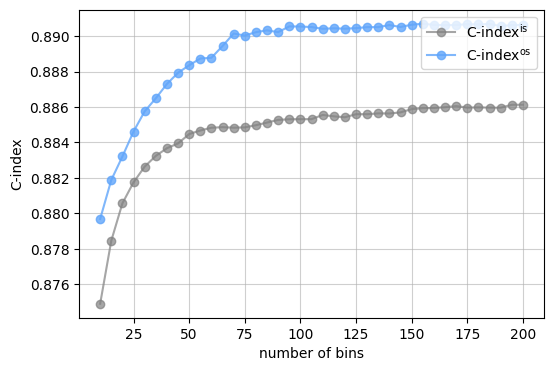

In [20]:
# --- plot ---
plt.figure(figsize=(6, 4))
plt.plot(bin_values, c_train_results, marker='o', label=r"C-index$^{\text{is}}$", color='gray', alpha=0.7)
plt.plot(bin_values, c_test_results, marker='o', label=r"C-index$^{\text{os}}$", color='#60A5FA',  alpha=0.8)
plt.xlabel("number of bins")
plt.ylabel("C-index")
plt.legend(loc = 'upper right') 
plt.grid(True, alpha=0.6)
plt.savefig(f'c_cali.png', format='png', dpi=300, bbox_inches='tight')
plt.show()